### ANALYZING BOOKING TRENDS IN THE HOSPITALITY INDUSTRY FOR HOTEL HAVEN
#### Creating predictive model to determine the booking status of customers for Hotel Haven
##### Hotel Haven has been facing challenges like 
* Customer cancellations
* Understand their customers booking patterns
* Create strategies that could improve customer retention and reduce cancellations.

#### Case Study: Predicting Customers Cancellation for Hotel Haven
##### Project to enhance Business Growth for Hotel Haven
##### 1.Business Problem Understanding
##### 2.Data Preprocessing and Cleaning
##### 3.Addressing Class Imbalance
##### 4.Model Development and Evaluation
##### 5.Interpreting Model Results¶
##### 6.AutoML Techniques

# ---
## Section 1: Import libraries 🤔

In [224]:
# Import libraries

import  pandas as pd   #dataframes for working with tabular data
import numpy  as np  # numerical operations

#visulization
import matplotlib.pyplot as plt 
import seaborn as sns

#scikit learn  machine learning 
# Machine preprocessing 
from sklearn.model_selection import train_test_split   # split data into train/test sets
from sklearn.preprocessing import StandardScaler  # standardize numerical features / columns
from sklearn.preprocessing import LabelEncoder  # Encode categorical columns


#machine learning Model 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 


# Machine Learning Evaluation

from sklearn.metrics import (accuracy_score, 
                               precision_score, 
                               recall_score, 
                               f1_score, 
                               confusion_matrix,
                               classification_report, 
                               roc_auc_score,
                               roc_curve)

#Setting
import warnings
warnings.filterwarnings('ignore')

sns.set_style ('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

#Set random seed for reproducility

RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


In [225]:
Data_booking = "booking1.xlsx"

df = pd.read_excel(Data_booking)

print("Data loaded successfully!")
print(f"shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("data loaded successfully")

Data loaded successfully!
shape: 36285 rows x 17 columns
data loaded successfully


# ---
## Section 2: Data Understanding

In [226]:
#### lets look at what we are working with, lets see the first 5 rows

### Print top 5 Rows

df.head(5)

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,2015-02-10 00:00:00,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,2018-06-11 00:00:00,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,2018-11-04 00:00:00,Canceled


In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

#### There are no missing values in the data

In [298]:
df.describe()

NameError: name 'df1' is not defined

In [229]:
df.describe(include=["object", "bool"])

,Booking_ID,type of meal,room type,market segment type,date of reservation,booking status
count,36285,36285,36285,36285,36285,36285
unique,36285,4,7,5,553,2
top,INN36286,Meal Plan 1,Room_Type 1,Online,10/13/2018,Not_Canceled
freq,1,27842,28138,23221,254,24396


### Handling Missing Values

In [230]:
df.duplicated().sum()

np.int64(0)

#### No Duplicates

In [231]:
df.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [232]:
df = df.rename(columns={"number of adults": "No_of_adult",
                        "number of children": "No_of_children",
                        "number of weekend nights": "No_of_weekendnights",
                        "number of week nights": "No_of weeknights",
                        "number of week nights": "No_of weeknights",
                        "type of meal": "Meal_type",
                        "car parking space": "Car_parking",
                        "room type": "Room_type",
                        "lead time": "Lead_time",
                       "market segment type": "Market_seg_type",
                        "average price": "Average_price",
                        "special requests": "Special_request",
                        "date of reservation": "Date_of_reservation"})
                        

Not_Canceled (0): 24,396  (67.2%)
Canceled (1):    11,889  (32.8%)


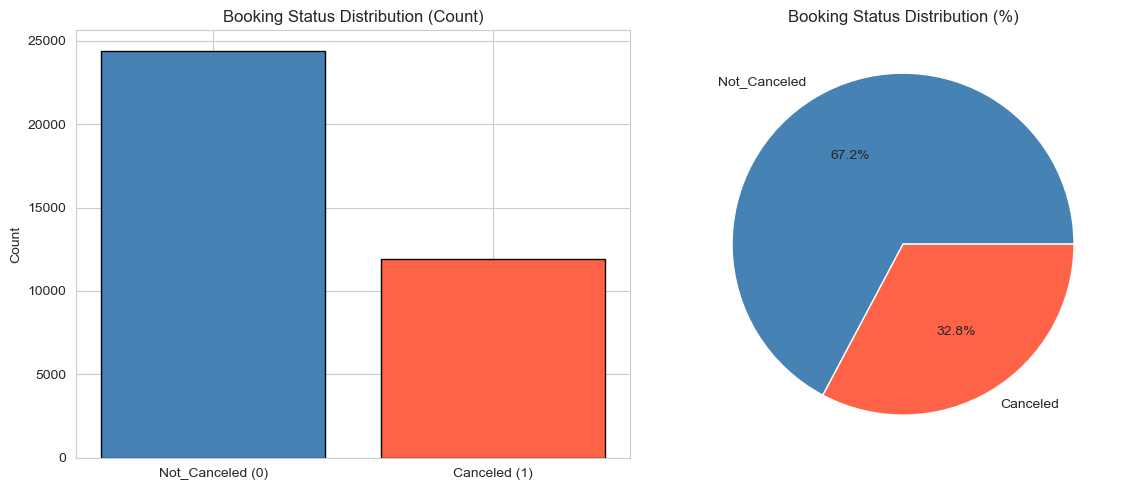

In [233]:
target_counts = df['booking status'].value_counts()
target_pct = df['booking status'].value_counts(normalize=True) * 100

print(f"Not_Canceled (0): {target_counts.iloc[0]:,}  ({target_pct.iloc[0]:.1f}%)")
print(f"Canceled (1):    {target_counts.iloc[1]:,}  ({target_pct.iloc[1]:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Not_Canceled (0)', 'Canceled (1)'], target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Booking Status Distribution (Count)')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=['Not_Canceled', 'Canceled'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Booking Status Distribution (%)')

plt.tight_layout()
plt.show()

In [234]:
numerical_cols = ['No_of_adult', 'No_of_children', 'No_of_weekendnights', 'No_of weeknights',
                  'Car_parking', 'Lead_time', 'repeated',
                  'P-C', 'P-not-C', 'Average_price', 'Special_request']

categorical_cols = ['Room_type', 'booking status', 'Market_seg_type',
                    'Meal_type']

print(f"Numerical ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

Numerical (11): ['No_of_adult', 'No_of_children', 'No_of_weekendnights', 'No_of weeknights', 'Car_parking', 'Lead_time', 'repeated', 'P-C', 'P-not-C', 'Average_price', 'Special_request']
Categorical (4): ['Room_type', 'booking status', 'Market_seg_type', 'Meal_type']


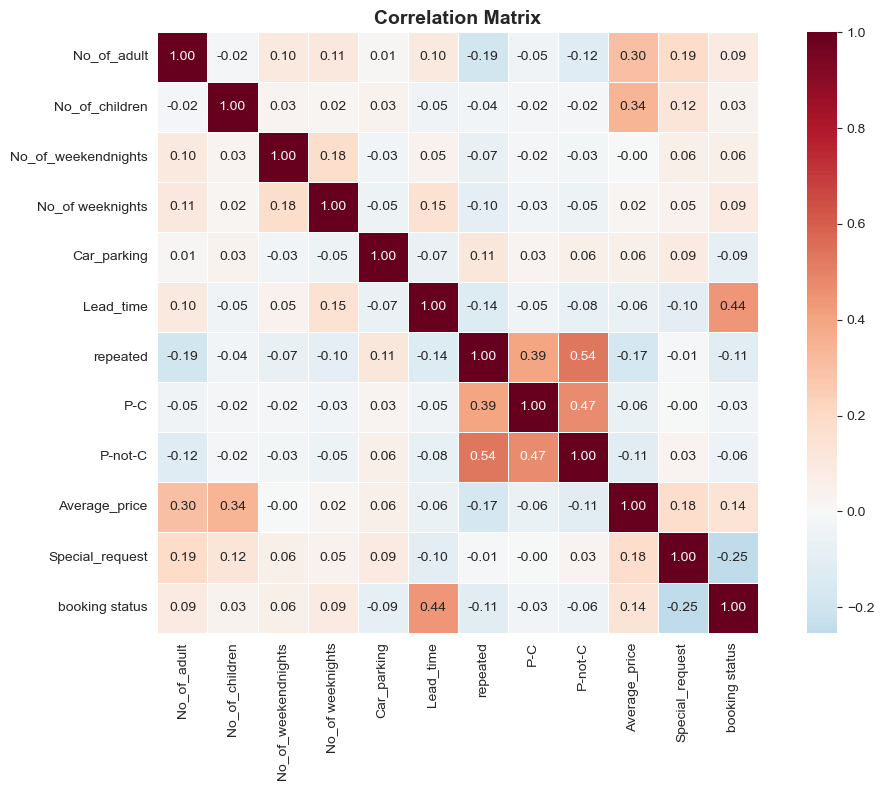

Correlations with booking (sorted):
Lead_time              0.438491
Special_request       -0.253092
Average_price          0.142433
repeated              -0.107277
No_of weeknights       0.092824
No_of_adult            0.086774
Car_parking           -0.086179
No_of_weekendnights    0.061489
P-not-C               -0.060174
P-C                   -0.033725
No_of_children         0.033007
Name: booking status, dtype: float64


In [235]:
# Correlation heatmap — shows relationships between numerical features and booking status

# Values closer to +1 or -1 = stronger relationship

#### Mapping the column booking status with 0 and 1 to enbble pandas read it

df['booking status'] = df['booking status'].map({'Not_Canceled': 0, 'Canceled': 1})

corr_cols = numerical_cols + ['booking status']
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show which features correlate most with the target
print("Correlations with booking (sorted):")
print(correlation_matrix['booking status'].drop('booking status').sort_values(key=abs, ascending=False))


In [236]:
# TASK: Find the top 3 features most correlated with the target variable
# HINT: First, create a correlation series: corr = df.corr()
# HINT: Get absolute values and sort in descending order
# HINT: Extract indices [1:4] (skip the first which is the target with itself)

# Get correlation with target, take absolute values, and sort
corr_target = correlation_matrix["booking status"].abs().sort_values(ascending=False)

# Get top 3 features (excluding the target itself)
top_3_features = corr_target[1:4]

print(top_3_features)

Lead_time          0.438491
Special_request    0.253092
Average_price      0.142433
Name: booking status, dtype: float64


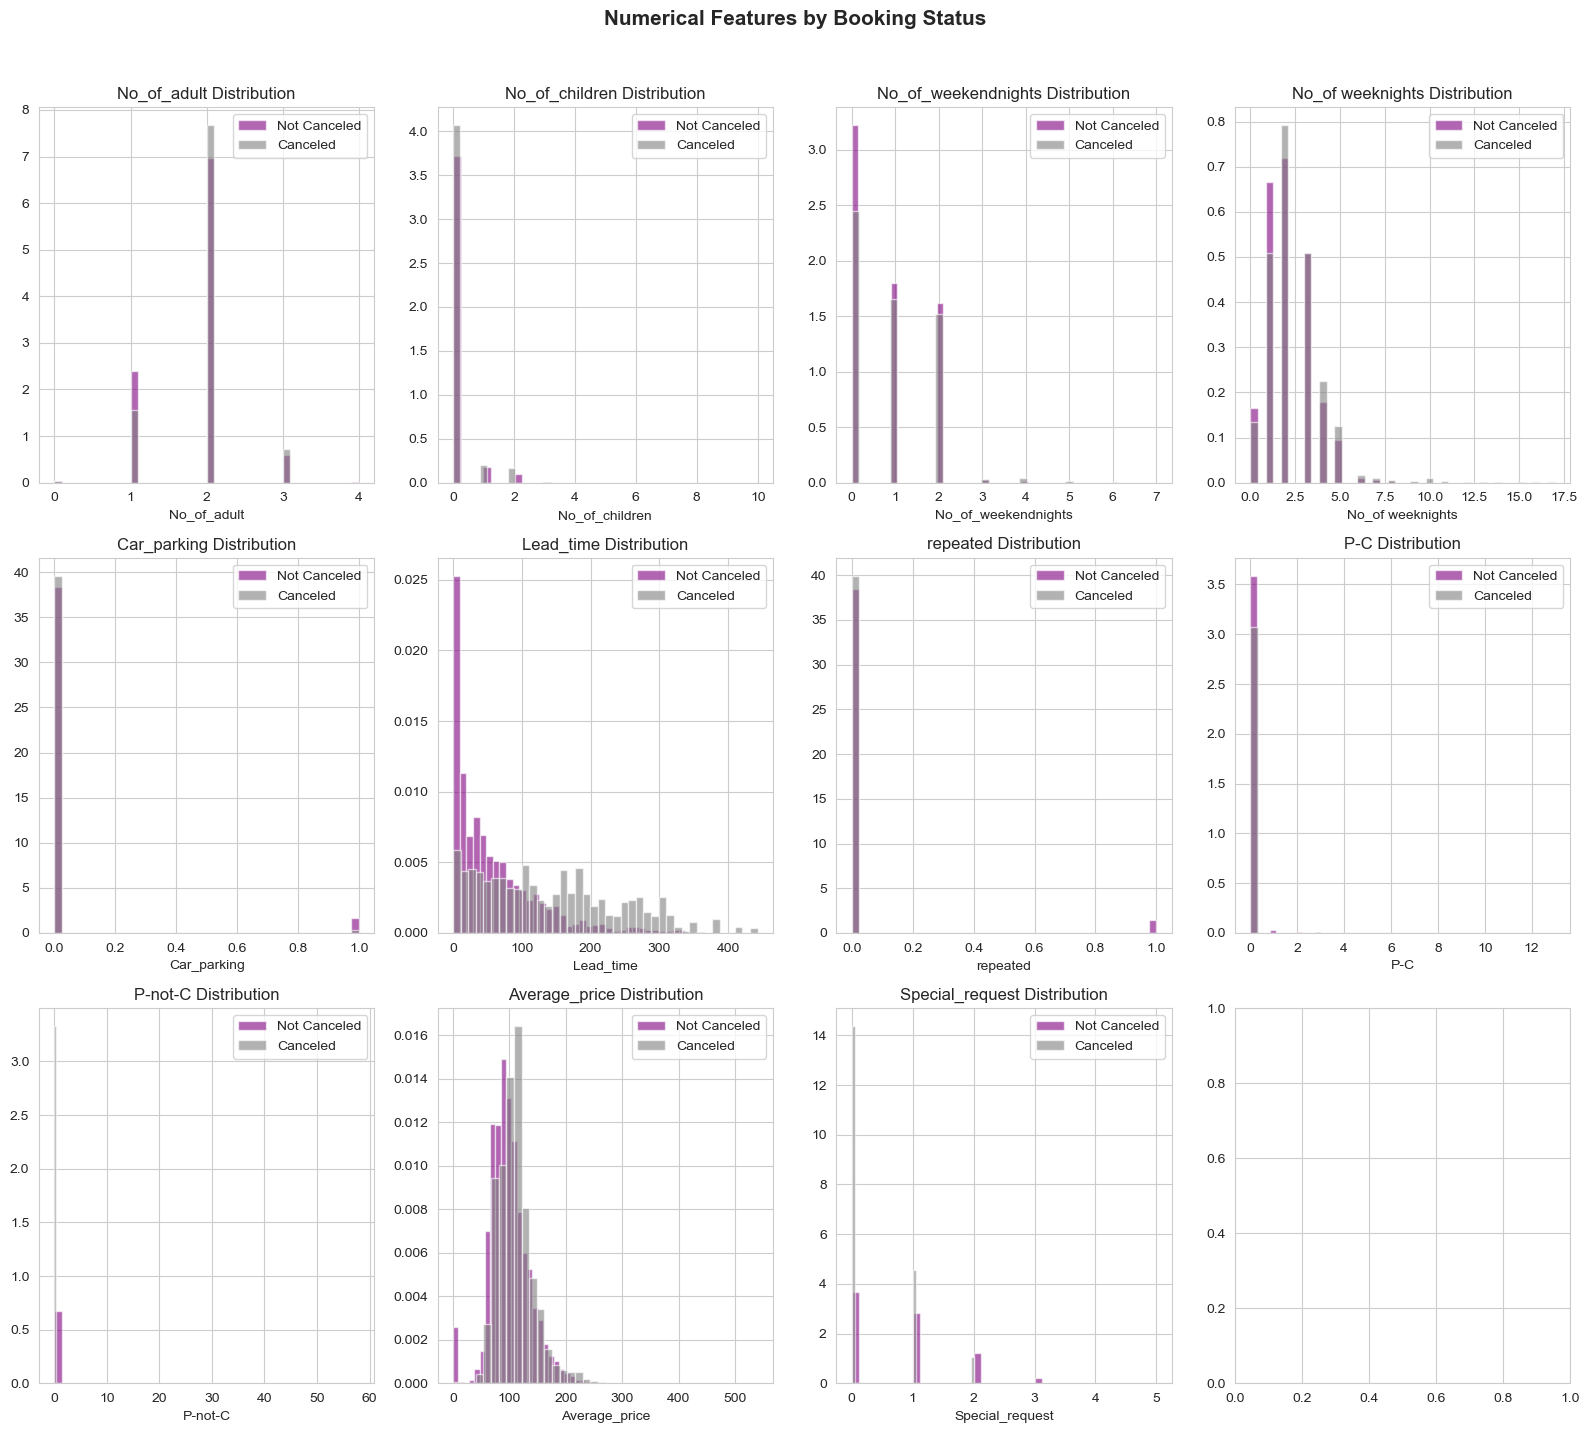

In [237]:
# Distributions of numerical features — split by booking status

# Purple= Not Canceled, Grey = Canceled

fig, axes = plt.subplots(3, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[df['booking status'] == 0][col], bins=40, alpha=0.6,
                 color='purple', label='Not Canceled', density=True)
    axes[i].hist(df[df['booking status'] == 1][col], bins=40, alpha=0.6,
                 color='grey', label='Canceled', density=True)
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].legend()
     

plt.suptitle('Numerical Features by Booking Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

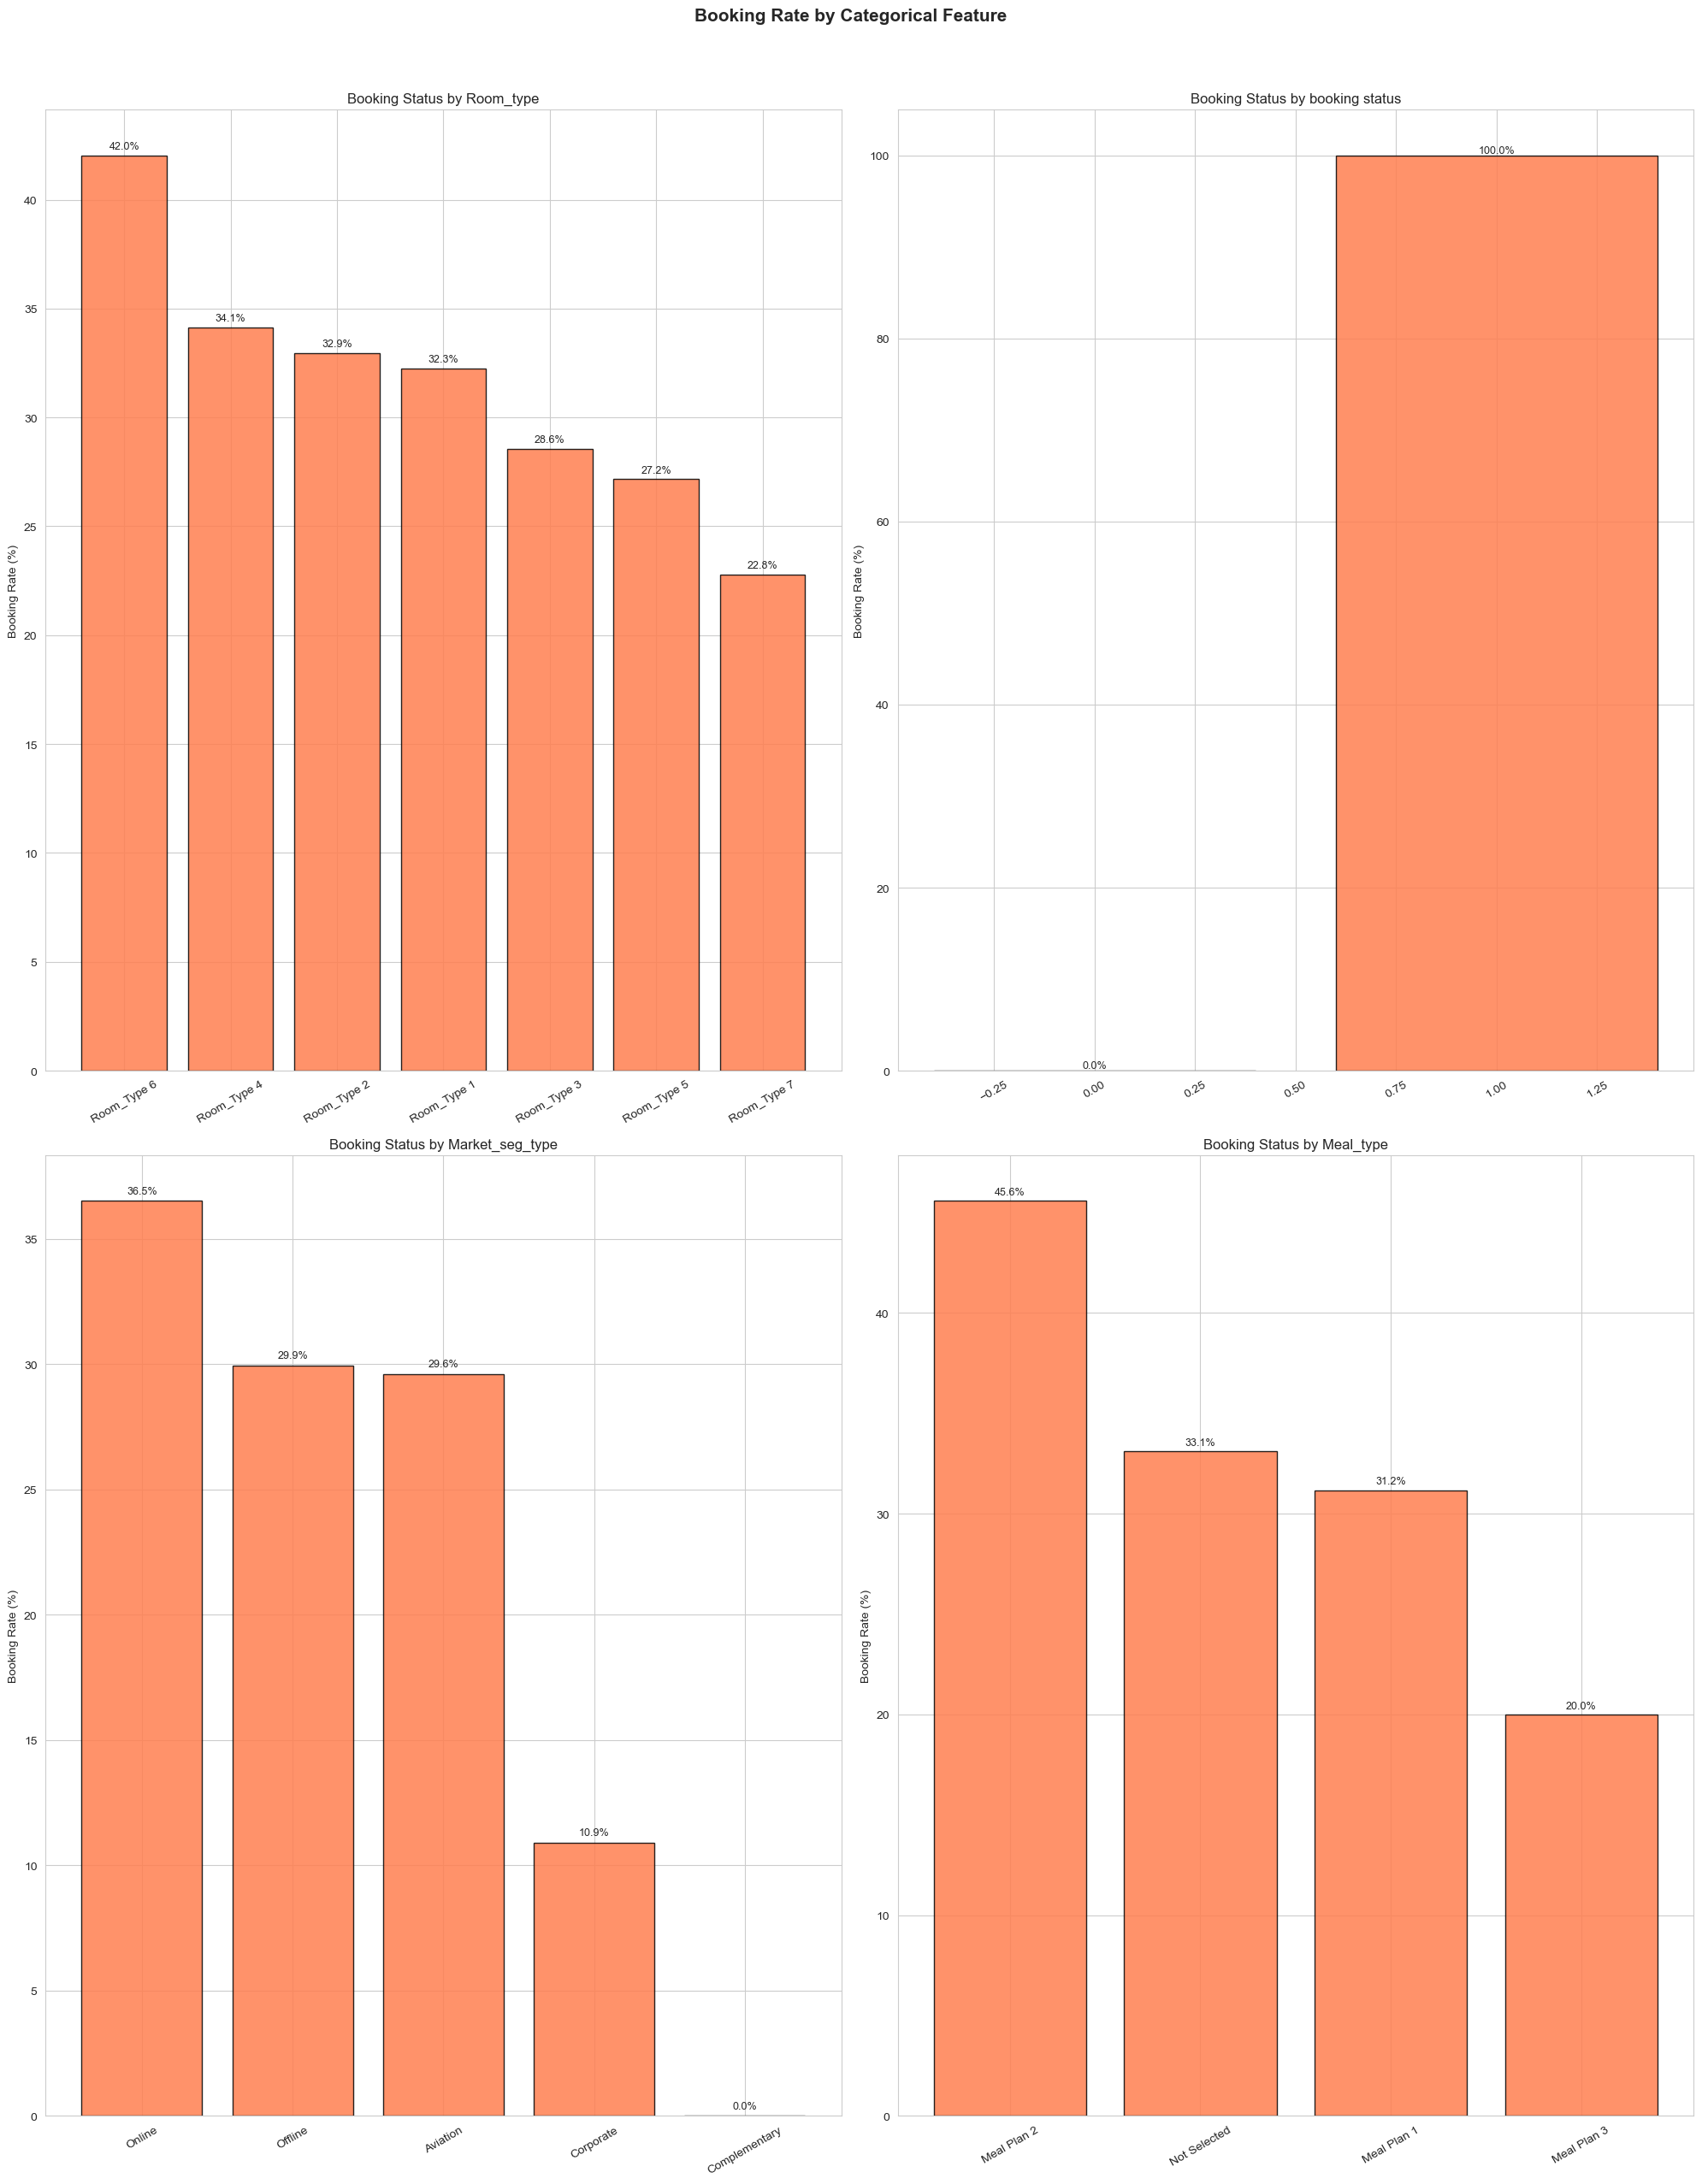

In [238]:
# Booking Status per category for each categorical feature

fig, axes = plt.subplots(2, 2, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate Booking Status (proportion) per category
    booking_rate = df.groupby(col)['booking status'].mean() * 100
    booking_rate = booking_rate.sort_values(ascending=False)

    bars = axes[i].bar(booking_rate.index, booking_rate.values,
                       color='coral', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Booking Status by {col}')
    axes[i].set_ylabel('Booking Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

    for bar, val in zip(bars, booking_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Booking Rate by Categorical Feature', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Time Series
##### *Show bad date
##### *Split into month and year
##### *Use coerce to remove bad dates

In [239]:
# Show the rows where the date conversion failed
bad_dates = df[df["Date_of_reservation"].isna()]
print(bad_dates)

Empty DataFrame
Columns: [Booking_ID, No_of_adult, No_of_children, No_of_weekendnights, No_of weeknights, Meal_type, Car_parking, Room_type, Lead_time, Market_seg_type, repeated, P-C, P-not-C, Average_price, Special_request, Date_of_reservation, booking status]
Index: []


In [240]:
# Convert to datetime safely
### IMPORTANT: Check if any NaT values were created
print(f"Number of invalid dates found: {df['Date_of_reservation'].isna().sum()}")

df["Date_of_reservation"] = pd.to_datetime(
    df["Date_of_reservation"],
    errors="coerce")

# Check invalid dates
print(df["Date_of_reservation"].isnull().sum())

Number of invalid dates found: 0
37


In [241]:
# Extract year
df["Year"] = df["Date_of_reservation"].dt.year

# Extract month
df["Month"] = df["Date_of_reservation"].dt.month

In [242]:
df.head()

,Booking_ID,No_of_adult,No_of_children,No_of_weekendnights,No_of weeknights,Meal_type,Car_parking,Room_type,Lead_time,Market_seg_type,repeated,P-C,P-not-C,Average_price,Special_request,Date_of_reservation,booking status,Year,Month
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,2015-02-10,0,2015.0,2.0
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,2018-06-11,0,2018.0,6.0
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2018-02-28,1,2018.0,2.0
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,2017-05-20,1,2017.0,5.0
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,2018-11-04,1,2018.0,11.0


In [243]:
df.describe()

,No_of_adult,No_of_children,No_of_weekendnights,No_of weeknights,Car_parking,Lead_time,repeated,P-C,P-not-C,Average_price,Special_request,Date_of_reservation,booking status,Year,Month
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36248,36285.000000,36248.000000,36248.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733,2018-05-10 23:23:58.093136384,0.327656,2017.820100,6.963888
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015-02-10 00:00:00,0.000000,2015.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000,2018-02-11 00:00:00,0.000000,2018.000000,4.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000,2018-06-03 12:00:00,0.000000,2018.000000,7.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000,2018-09-13 00:00:00,1.000000,2018.000000,10.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000,2018-12-31 00:00:00,1.000000,2018.000000,12.000000
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262,NaN,0.469365,0.384396,3.257583


In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Booking_ID           36285 non-null  object        
 1   No_of_adult          36285 non-null  int64         
 2   No_of_children       36285 non-null  int64         
 3   No_of_weekendnights  36285 non-null  int64         
 4   No_of weeknights     36285 non-null  int64         
 5   Meal_type            36285 non-null  object        
 6   Car_parking          36285 non-null  int64         
 7   Room_type            36285 non-null  object        
 8   Lead_time            36285 non-null  int64         
 9   Market_seg_type      36285 non-null  object        
 10  repeated             36285 non-null  int64         
 11  P-C                  36285 non-null  int64         
 12  P-not-C              36285 non-null  int64         
 13  Average_price        36285 non-

In [245]:
df.isnull().sum()
#### we will see the missing values in the bad dates, we will not be manipulating the datea

Booking_ID              0
No_of_adult             0
No_of_children          0
No_of_weekendnights     0
No_of weeknights        0
Meal_type               0
Car_parking             0
Room_type               0
Lead_time               0
Market_seg_type         0
repeated                0
P-C                     0
P-not-C                 0
Average_price           0
Special_request         0
Date_of_reservation    37
booking status          0
Year                   37
Month                  37
dtype: int64

In [246]:
### values that are abnormal which are not confirming to the norm

numerical_columns = df.select_dtypes(include="number")
len(numerical_columns.columns)

14

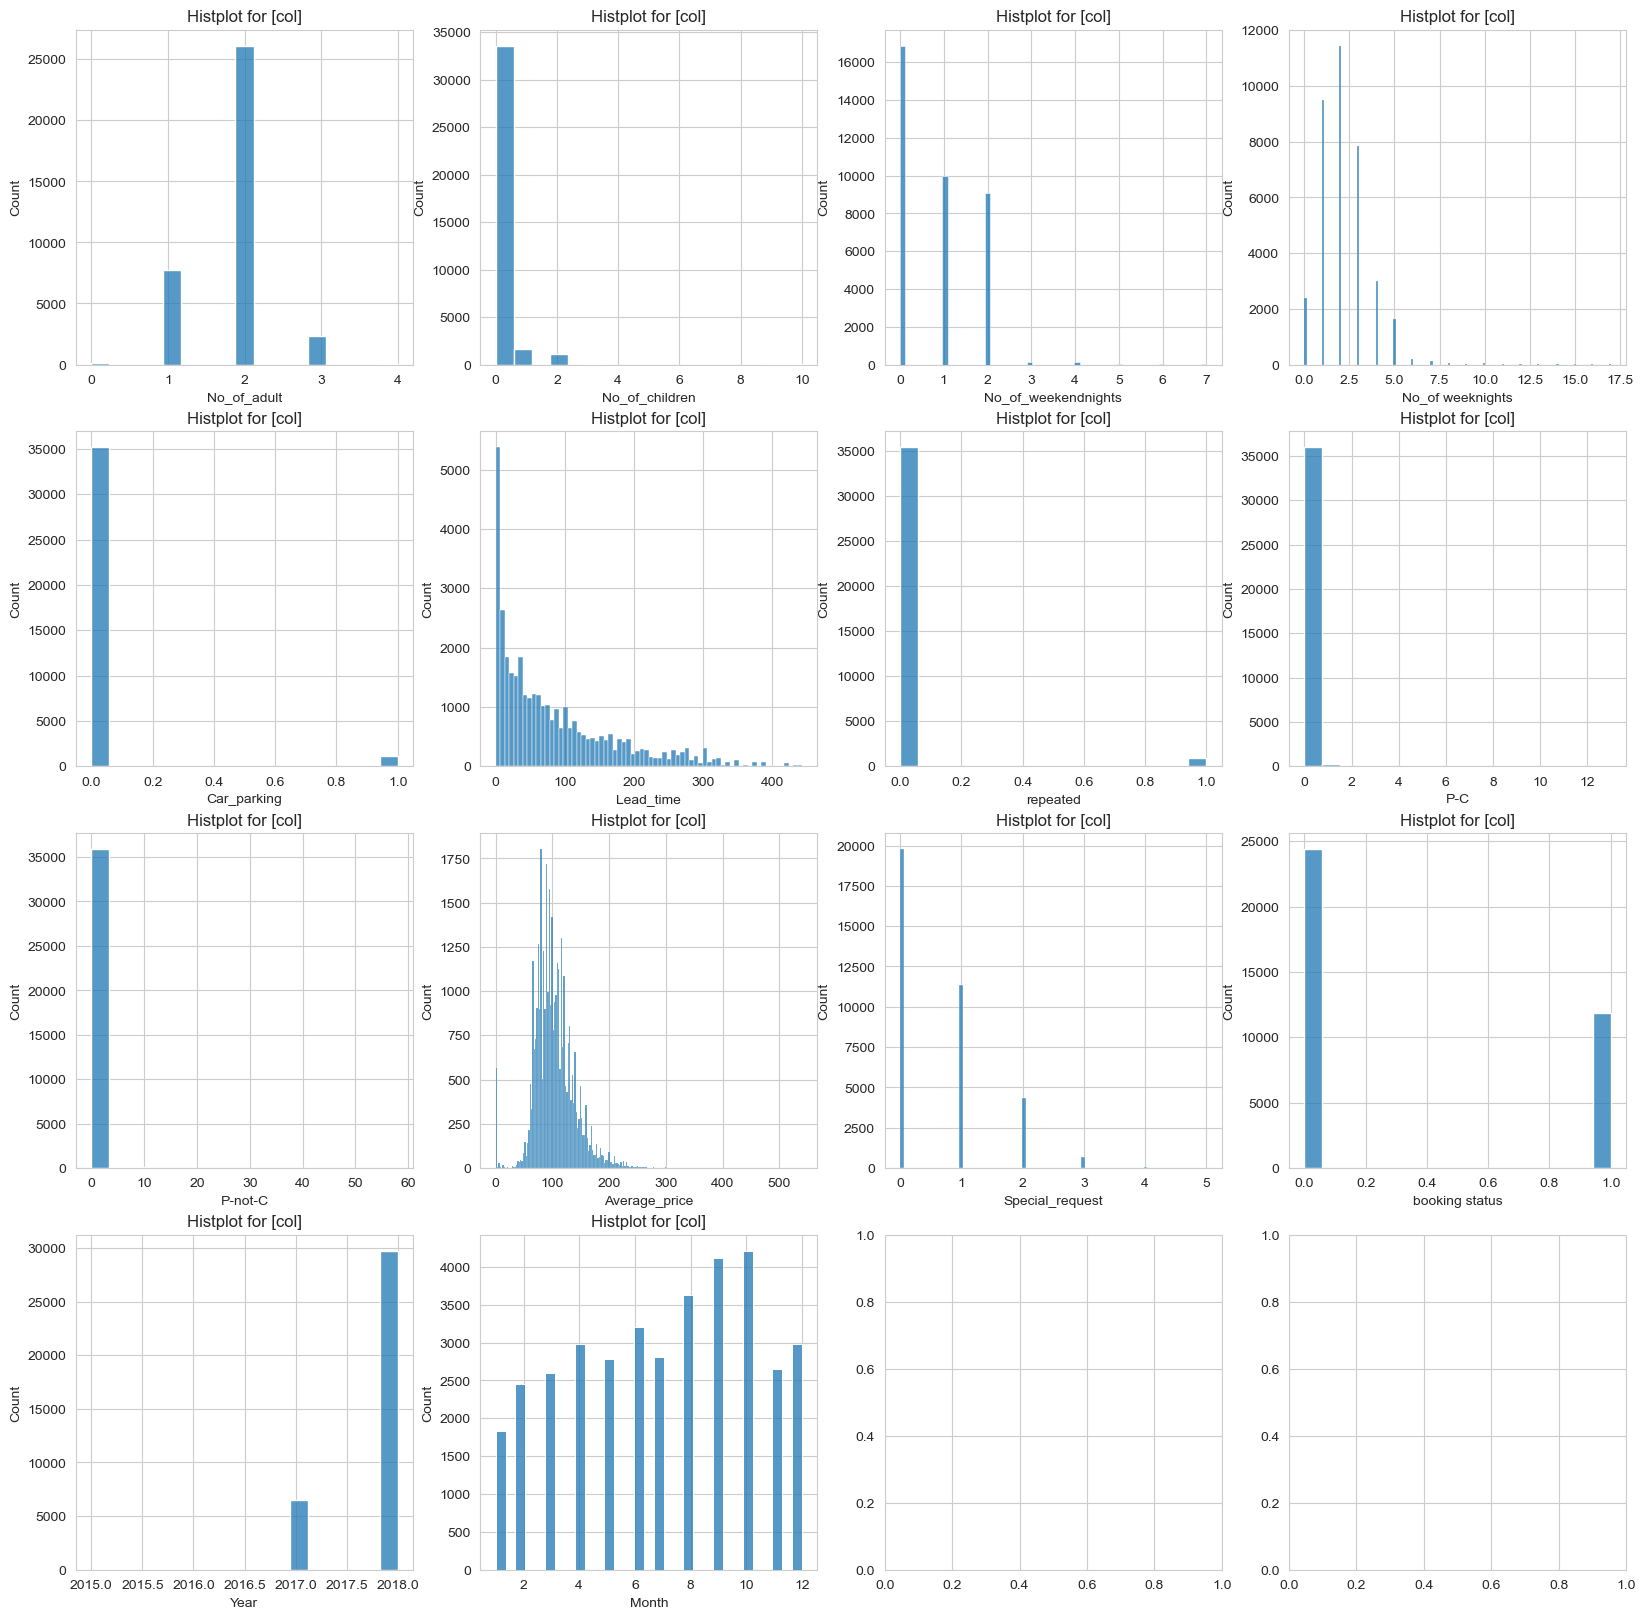

In [247]:
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(20,20))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax=ax[idx])
    ax[idx].set_title(f"Histplot for [col]")
plt.show()

#### TASK: Detect outliers in 'Numerical col' using the IQR (Interquartile Range) method
#####  Calculate Q1 using .quantile(0.25
#####  Calculate Q3 using .quantile(0.75)
#####  Calculate IQR = Q3 - Q1
#####  Define bounds: lower = Q1 - 1.5*IQR, upper = Q3 + 1.5*IQR
#####  Find outliers where values fall outside these bounds


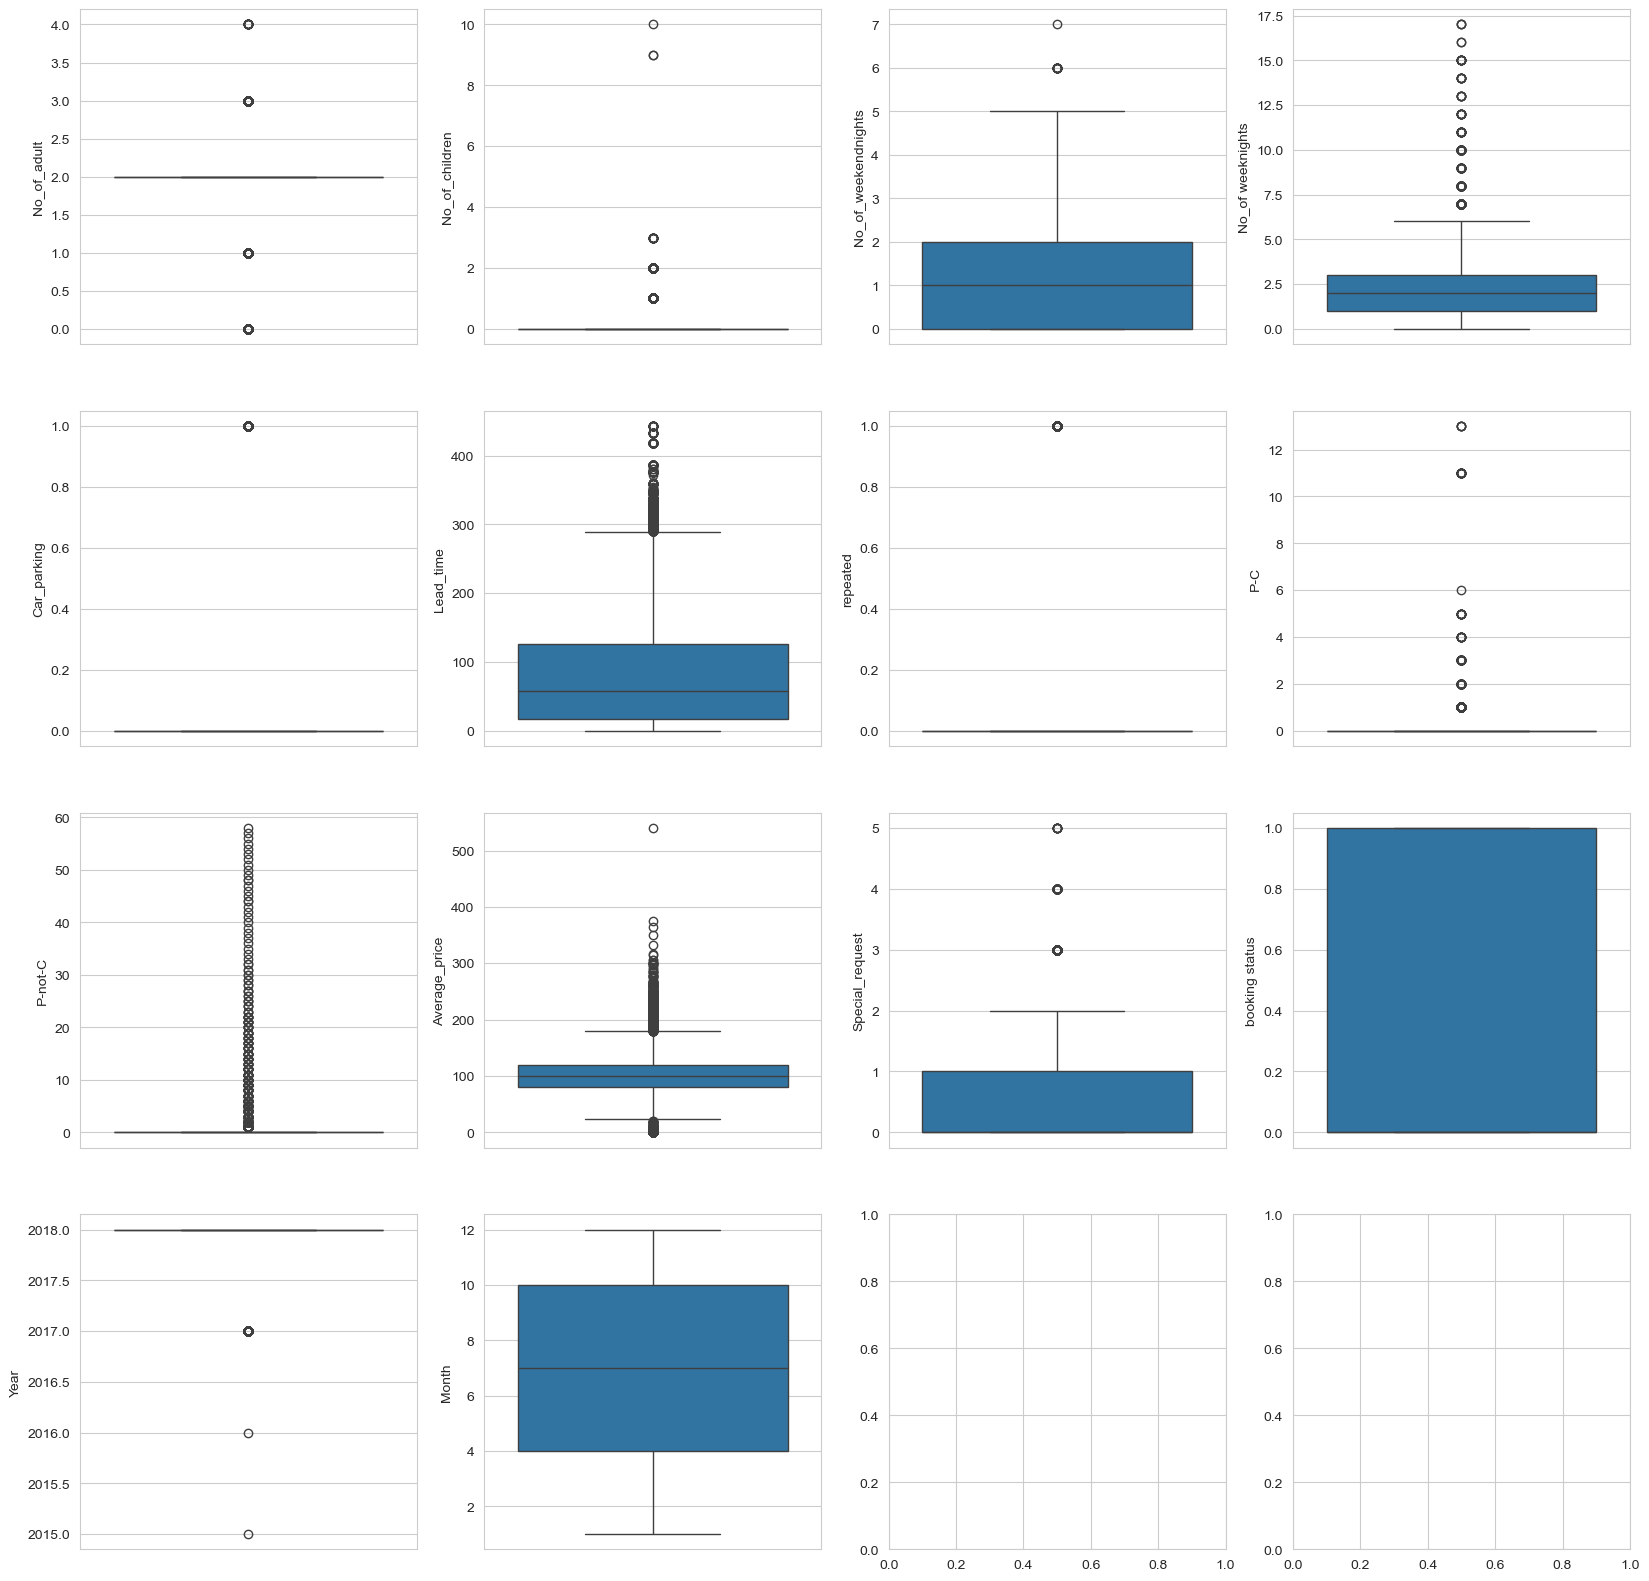

In [248]:
fig, ax = plt.subplots(nrows=4,ncols=4, figsize=(20,20))
ax = ax.flatten()
for idx, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=ax[idx])
plt.show()

In [249]:
cols = ("NO_of weeknights", "Car_parking", "Average_price", "P-not-C", "No_of_weekendnights", "Special_request", "Lead_time", "No_of_adult")
for idx in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Outliers removed")

Outliers removed


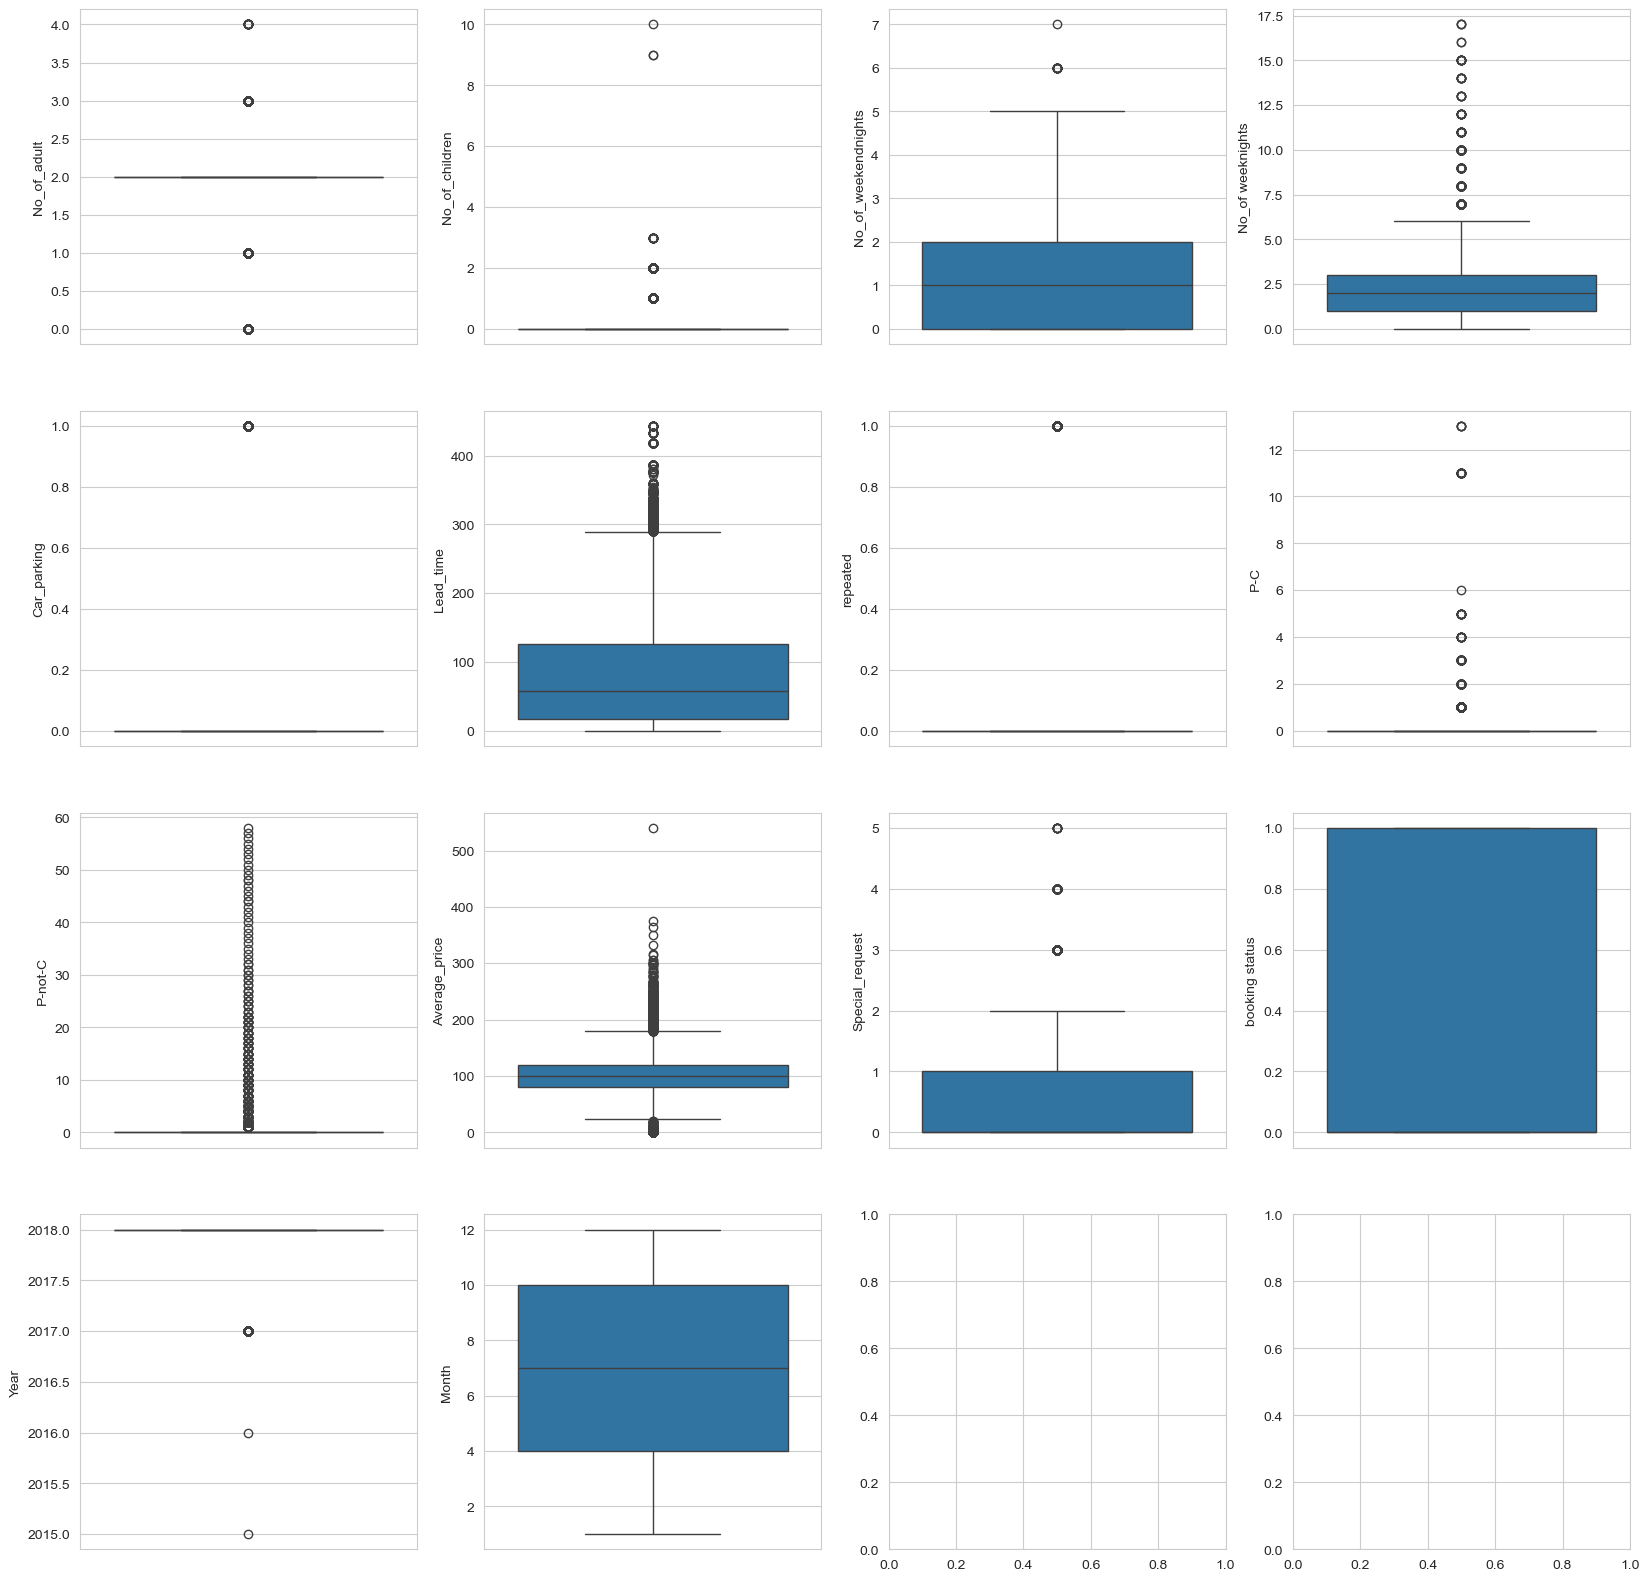

In [250]:
fig, ax = plt.subplots(nrows=4,ncols=4, figsize=(20,20))
ax = ax.flatten()
for idx, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=ax[idx])
plt.show()

In [251]:
Special_request = df.groupby("booking status")["Booking_ID"].count()
print(Special_request)

booking status
0    24366
1    11882
Name: Booking_ID, dtype: int64


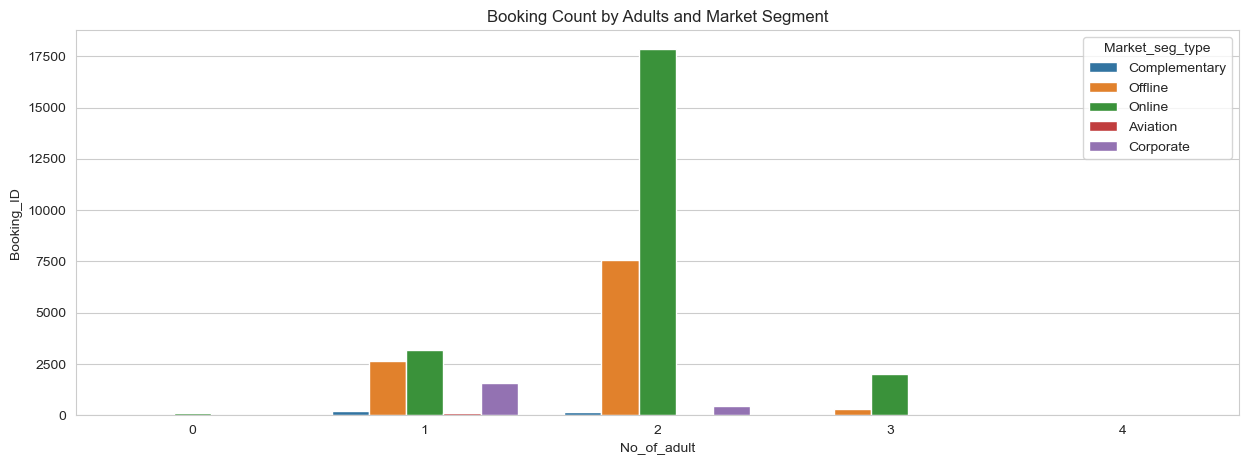

In [252]:
adult_perf = df.groupby(["No_of_adult", "Market_seg_type"])["Booking_ID"].count().reset_index()

plt.figure(figsize=(15,5))
sns.barplot(x="No_of_adult",y="Booking_ID",data=adult_perf,hue="Market_seg_type")

plt.title("Booking Count by Adults and Market Segment")
plt.show()

#### Looking through the Time chart series

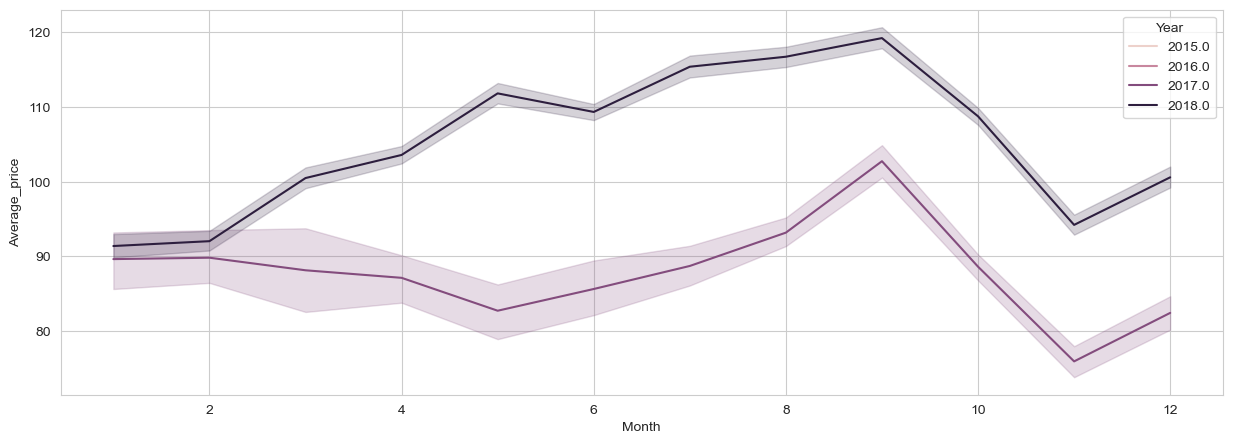

In [253]:
plt.figure(figsize=(15,5))
sns.lineplot(x='Month', y='Average_price', data=df, hue='Year');

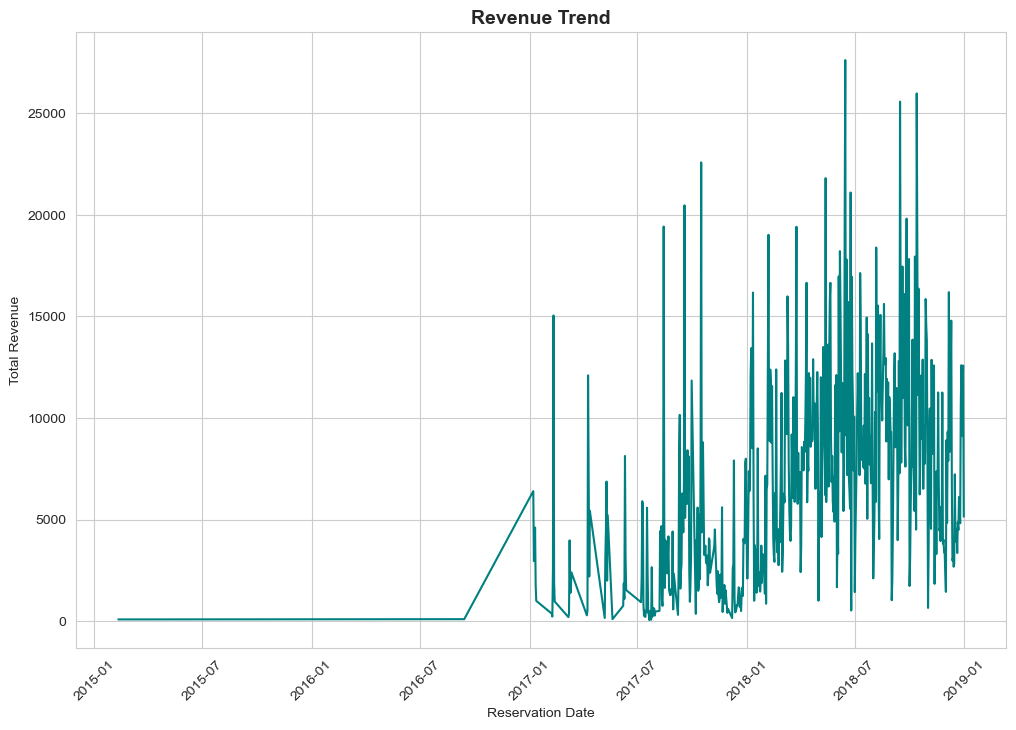

In [254]:
# 1. Let visualize the relationship between Revenue and date of Reservations
daily_revenue = df.groupby("Date_of_reservation")["Average_price"].sum().reset_index()

# 2. Create the figure and axis correctly
fig, ax = plt.subplots(figsize=(12, 8))

# 3. Draw the lineplot onto the 'ax' we just created
sns.lineplot(x='Date_of_reservation', y='Average_price', data=daily_revenue, ax=ax, color='teal')

# 4. Set labels using the 'ax' object
ax.set_title("Revenue Trend", fontsize=14, fontweight='bold')
ax.set_xlabel("Reservation Date")
ax.set_ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()

In [255]:
df.columns

Index(['Booking_ID', 'No_of_adult', 'No_of_children', 'No_of_weekendnights',
       'No_of weeknights', 'Meal_type', 'Car_parking', 'Room_type',
       'Lead_time', 'Market_seg_type', 'repeated', 'P-C', 'P-not-C',
       'Average_price', 'Special_request', 'Date_of_reservation',
       'booking status', 'Year', 'Month'],
      dtype='object')

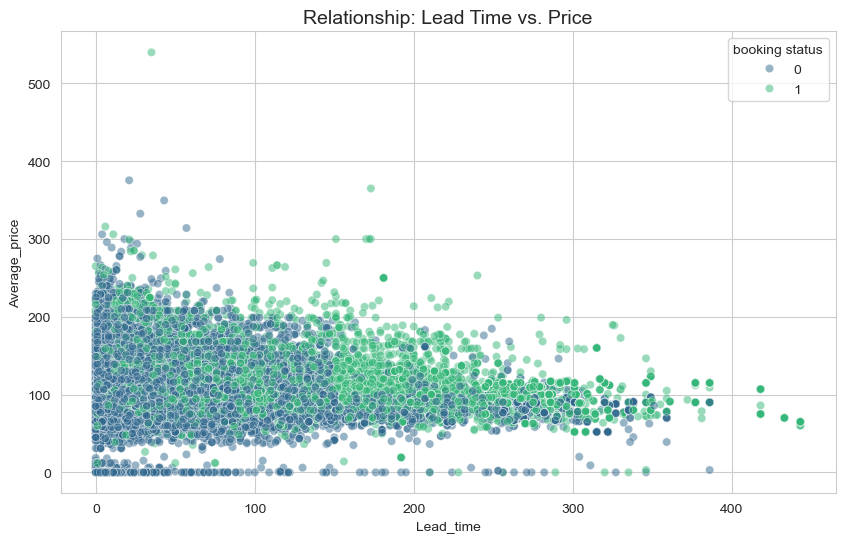

In [256]:
# Create a scatter plot with a "trend line" and color coding to show relationship between lead time, Avg_price and booking status
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Lead_time', 
    y='Average_price', 
    hue='booking status', # Color the dots by status
    alpha=0.5,            # Make dots slightly transparent to see density
    palette='viridis'
)

plt.title('Relationship: Lead Time vs. Price', fontsize=14)
plt.show()

<Axes: xlabel='No_of_adult', ylabel='Average_price'>

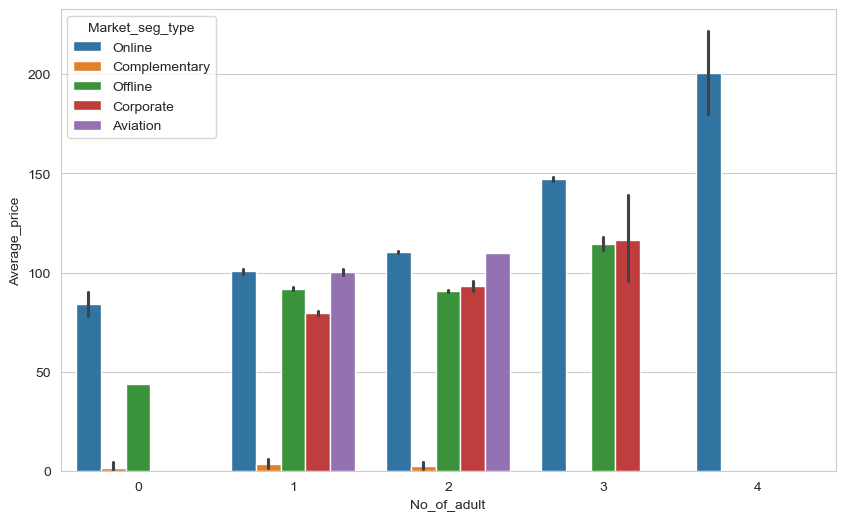

In [257]:
sns.barplot(
    x="No_of_adult",
    y="Average_price",
    data=df,
    hue="Market_seg_type")


In [258]:
# Check for missing values in each column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

Missing values per column:
No missing values found!


In [259]:
# Check for and remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicate rows: 0


In [260]:
# Drop LoanID — it's a unique identifier with no predictive value
df = df.drop(columns=['Booking_ID'])

print(f"Booking_ID dropped. Remaining shape: {df.shape}")

Booking_ID dropped. Remaining shape: (36248, 18)


---
##  Data Preprocessing

ML models only understand **numbers**. We need to convert text/categories to numerical format.

**Encoding strategies:**
- **Binary map (Yes→1, No→0)** for columns with only two values
- **One-Hot Encoding** for categories with no natural order (creates a new 0/1 column per category)

**Feature Scaling:**  
- `StandardScaler` transforms each feature to have **mean=0** and **standard deviation=1**  
- Prevents features with large values (like Income) from dominating the model
- #### ---------------
###### * Transform the data set
###### * Standardize the data set
###### * Split and Train the data set
###### * Run the model to prdeict
###### * Validate the Model

In [261]:
df.head(10)

,No_of_adult,No_of_children,No_of_weekendnights,No_of weeknights,Meal_type,Car_parking,Room_type,Lead_time,Market_seg_type,repeated,P-C,P-not-C,Average_price,Special_request,Date_of_reservation,booking status,Year,Month
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,2015-02-10,0,2015.0,2.0
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,2018-06-11,0,2018.0,6.0
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2018-02-28,1,2018.0,2.0
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,2017-05-20,1,2017.0,5.0
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,2018-11-04,1,2018.0,11.0
5,1,0,0,2,Meal Plan 2,0,Room_Type 1,346,Offline,0,0,0,100.00,1,2016-09-13,1,2016.0,9.0
6,1,1,1,4,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,2017-10-15,0,2017.0,10.0
7,3,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,0,0,0,105.61,1,2018-12-26,0,2018.0,12.0
8,1,1,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,0,0,0,96.90,1,2018-06-07,0,2018.0,6.0
9,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,Online,0,0,0,133.44,3,2018-10-18,0,2018.0,10.0


In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36248 entries, 0 to 36284
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   No_of_adult          36248 non-null  int64         
 1   No_of_children       36248 non-null  int64         
 2   No_of_weekendnights  36248 non-null  int64         
 3   No_of weeknights     36248 non-null  int64         
 4   Meal_type            36248 non-null  object        
 5   Car_parking          36248 non-null  int64         
 6   Room_type            36248 non-null  object        
 7   Lead_time            36248 non-null  int64         
 8   Market_seg_type      36248 non-null  object        
 9   repeated             36248 non-null  int64         
 10  P-C                  36248 non-null  int64         
 11  P-not-C              36248 non-null  int64         
 12  Average_price        36248 non-null  float64       
 13  Special_request      36248 non-null 

In [263]:
df['repeated'].value_counts(normalize='true')*100

repeated
0    97.445376
1     2.554624
Name: proportion, dtype: float64

In [264]:
df_pro.columns

Index(['No_of_adult', 'No_of_children', 'No_of_weekendnights',
       'No_of weeknights', 'Meal_type', 'Car_parking', 'Room_type',
       'Lead_time', 'Market_seg_type', 'repeated', 'P-C', 'P-not-C',
       'Average_price', 'Special_request', 'Date_of_reservation',
       'booking status', 'Year', 'Month'],
      dtype='object')

In [265]:
from sklearn.preprocessing import StandardScaler

In [266]:
# Make a copy to keep the original intact
df_pro = df.copy()

print(f"New shape: {df_pro.shape}")
print(f"All dtypes numeric: {all(df_pro.dtypes != 'object')}")

New shape: (36248, 18)
All dtypes numeric: False


---
## Split Features/Target & Train/Test Split

- **X** = all input features (what the model uses to predict)
- **y** = the target variable (what we want to predict)

We split data into **80% training** and **20% test** sets.  
The model learns on training data and is evaluated on unseen test data.

> **`stratify=y`** ensures the same default/no-default ratio in both splits.

In [267]:
# X = all features (everything except the target column)
# Create a list of columns to drop that are not numbers
# We drop 'Date of reservation' because it's a date object
# We drop 'month' and Year because it's text (we already have 'month' as a number)

cols_to_drop = ["Date_of_reservation", "Month", "Year"]

# Drop them from your features (X)
X = df_pro.drop(columns=cols_to_drop + ["booking status"])

# 2. Convert any remaining categories or booleans to numbers
X = pd.get_dummies(X, drop_first=True)

# y = target variable only
y = df_pro['booking status']

print(f"X shape: {X.shape}  (samples × features)")
print(f"y shape: {y.shape}")

X shape: (36248, 24)  (samples × features)
y shape: (36248,)


In [270]:
from sklearn.model_selection import train_test_split


# SPLIT FIRST (To prevent leakage) ## Preserve class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test  default rate: {y_test.mean()*100:.2f}%")


Training set: 28,998 samples
Test set:     7,250 samples
Train default rate: 32.78%
Test  default rate: 32.79%


In [271]:
# Feature Scaling — fit ONLY on training data, then apply to both sets
# (Fitting on test data would cause data leakage)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # Fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # Transform only on test

print("Scaling complete.")
print(f"Train mean (≈0): {X_train_scaled.mean():.4f}")
print(f"Train std  (≈1): {X_train_scaled.std():.4f}")

Scaling complete.
Train mean (≈0): 0.0000
Train std  (≈1): 1.0000


---
##  Model Selection

We'll train three models and compare their performance:

| Model | Key Idea | Strengths | Weaknesses |
|---|---|---|---|
| **Logistic Regression** | Finds a linear decision boundary | Fast, interpretable | Assumes linearity |
| **Decision Tree** | Splits data with yes/no questions | Interpretable, handles non-linearity | Prone to overfitting |
| **Random Forest** | Combines 100s of decision trees | High accuracy, robust | Slower, less interpretable |

**scikit-learn pattern for every model:**
```python
model = ModelClass()          # 1. Create
model.fit(X_train, y_train)   # 2. Train
predictions = model.predict(X_test)  # 3. Predict

In [272]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)              # Class predictions (0 or 1)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability of default

print("Logistic Regression trained.")

Logistic Regression trained.


In [273]:
# ── Model 2: Decision Tree ────────────────────────────────────────────────────
# max_depth=5 limits tree depth to prevent overfitting
dt_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree trained.")

Decision Tree trained.


In [274]:
# ── Model 3: Random Forest ────────────────────────────────────────────────────
# n_estimators=100 → builds 100 decision trees and combines their votes
# n_jobs=-1 → use all CPU cores for faster training
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest trained.")

Random Forest trained.


---
## Model Evaluation

### Confusion Matrix
```
                    Predicted 0  |  Predicted 1
Actual 0  →   True Negative (TN) | False Positive (FP)
Actual 1  →  False Negative (FN) |  True Positive (TP)
```

### Key Metrics
| Metric | Formula | Meaning |
|---|---|---|
| **Accuracy** | (TP+TN)/Total | % of all correct Cancellations |
| **Precision** | TP/(TP+FP) | Of predicted Cancellations, how many were real? |
| **Recall** | TP/(TP+FN) | Of all real Cancellations, how many did we catch? |
| **F1** | 2×P×R/(P+R) | Balance of precision and recall |
| **ROC-AUC** | Area under curve | Overall ranking ability (0.5=random, 1.0=perfect) |

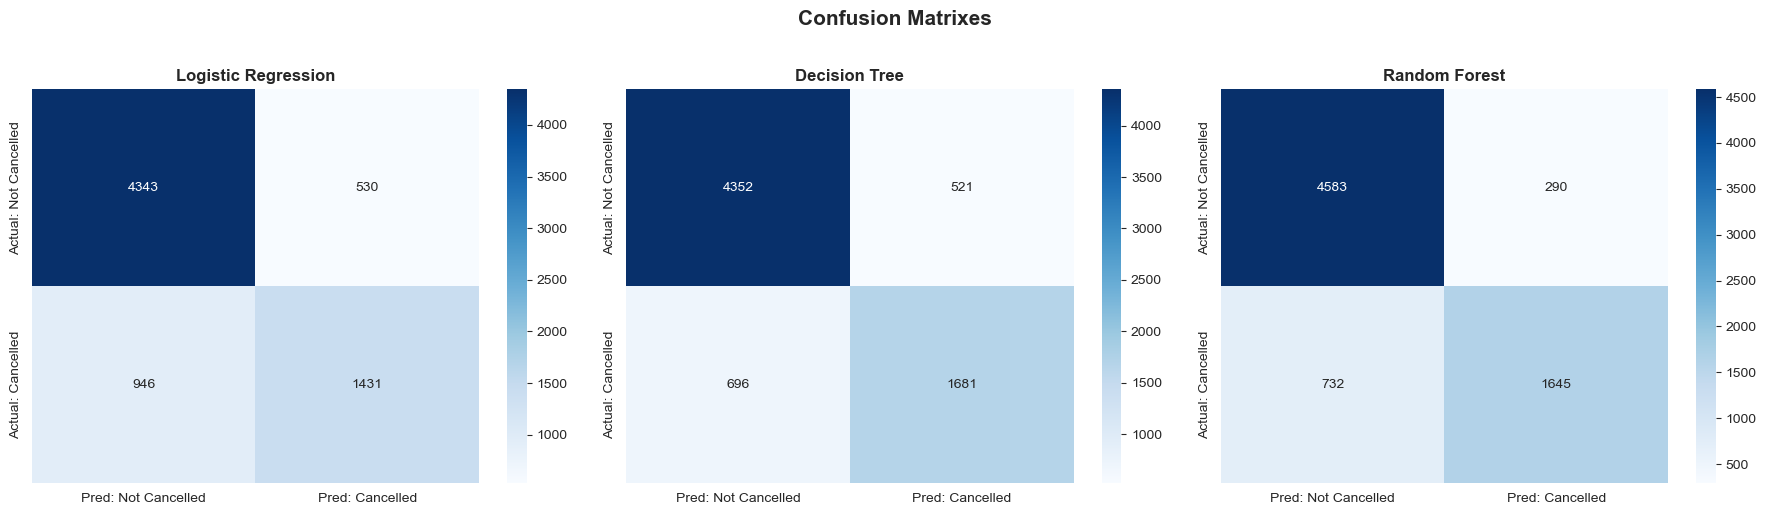

In [275]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree',       dt_pred),
    ('Random Forest',       rf_pred)
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                 xticklabels=['Pred: Not Cancelled', 'Pred: Cancelled'],
                yticklabels=['Actual: Not Cancelled', 'Actual: Cancelled'])
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Confusion Matrixes', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### * Trying out Multiple Models

In [276]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [277]:
# !pip install xgboost
from xgboost import XGBClassifier

In [278]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42,class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)}

In [279]:
models.items()

dict_items([('Logistic Regression', LogisticRegression(class_weight='balanced', random_state=42)), ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=42)), ('Gradient Boosting', GradientBoostingClassifier(random_state=42)), ('AdaBoost', AdaBoostClassifier(random_state=42)), ('SVM', SVC(class_weight='balanced', random_state=42)), ('KNN', KNeighborsClassifier()), ('Decision Tree', DecisionTreeClassifier(random_state=42))])

training Logistic Regression....
Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4873
           1       0.64      0.77      0.70      2377

    accuracy                           0.78      7250
   macro avg       0.76      0.78      0.76      7250
weighted avg       0.80      0.78      0.78      7250



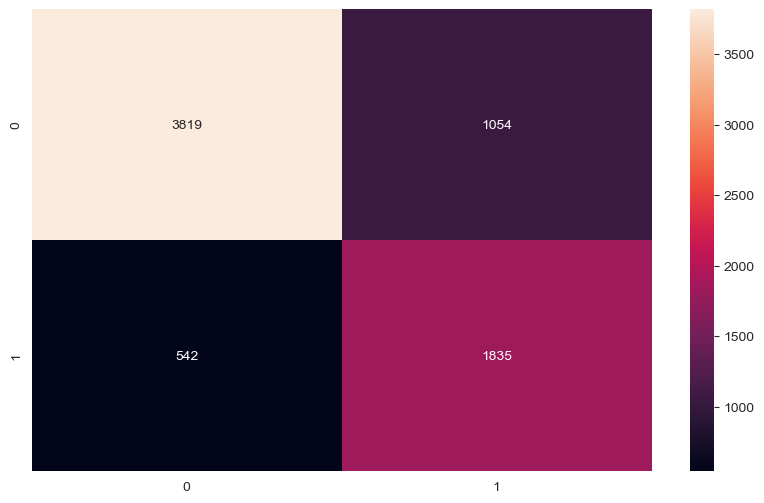

training Random Forest....
Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      4873
           1       0.86      0.79      0.82      2377

    accuracy                           0.89      7250
   macro avg       0.88      0.86      0.87      7250
weighted avg       0.89      0.89      0.89      7250



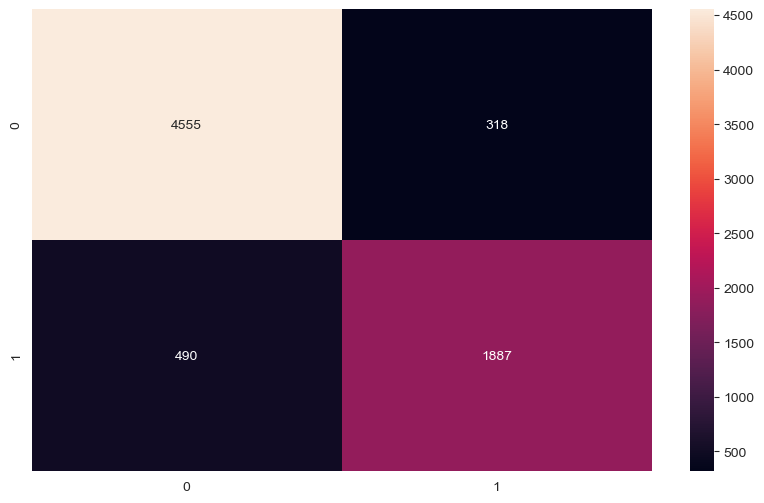

training Gradient Boosting....
Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4873
           1       0.82      0.69      0.75      2377

    accuracy                           0.85      7250
   macro avg       0.84      0.81      0.82      7250
weighted avg       0.85      0.85      0.85      7250



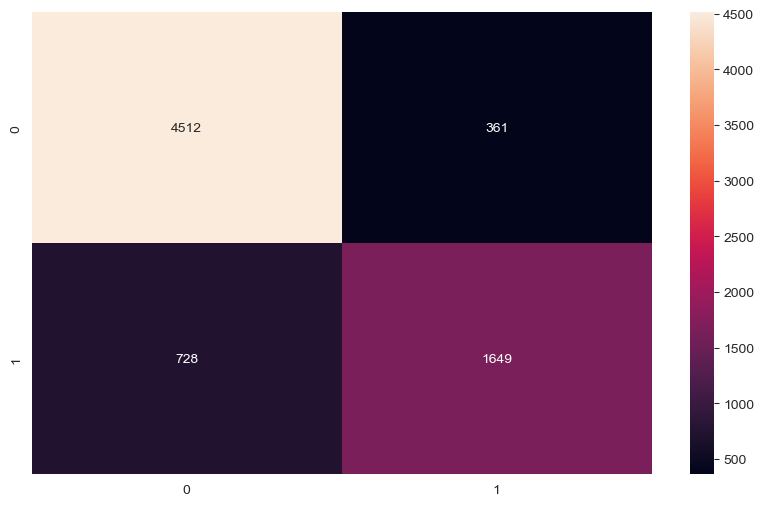

training AdaBoost....
AdaBoost Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      4873
           1       0.74      0.65      0.69      2377

    accuracy                           0.81      7250
   macro avg       0.79      0.77      0.78      7250
weighted avg       0.81      0.81      0.81      7250



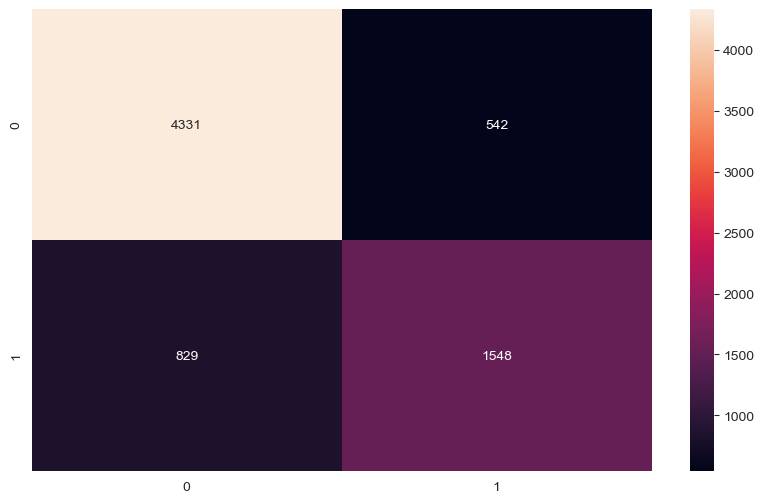

training SVM....
SVM Classification Report
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      4873
           1       0.65      0.80      0.72      2377

    accuracy                           0.79      7250
   macro avg       0.77      0.80      0.78      7250
weighted avg       0.81      0.79      0.80      7250



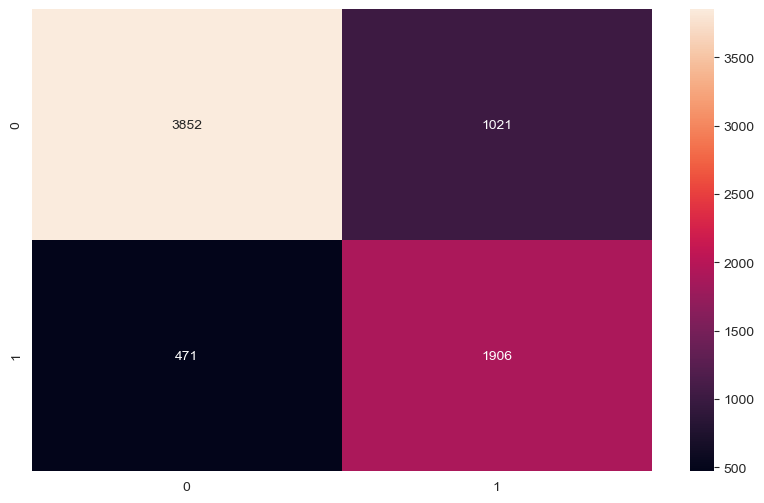

training KNN....
KNN Classification Report
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4873
           1       0.79      0.73      0.76      2377

    accuracy                           0.85      7250
   macro avg       0.83      0.82      0.83      7250
weighted avg       0.85      0.85      0.85      7250



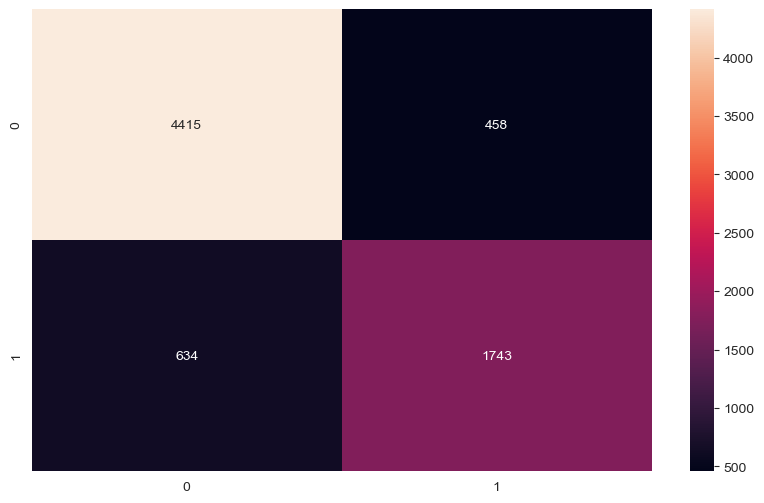

training Decision Tree....
Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      4873
           1       0.78      0.79      0.78      2377

    accuracy                           0.86      7250
   macro avg       0.84      0.84      0.84      7250
weighted avg       0.86      0.86      0.86      7250



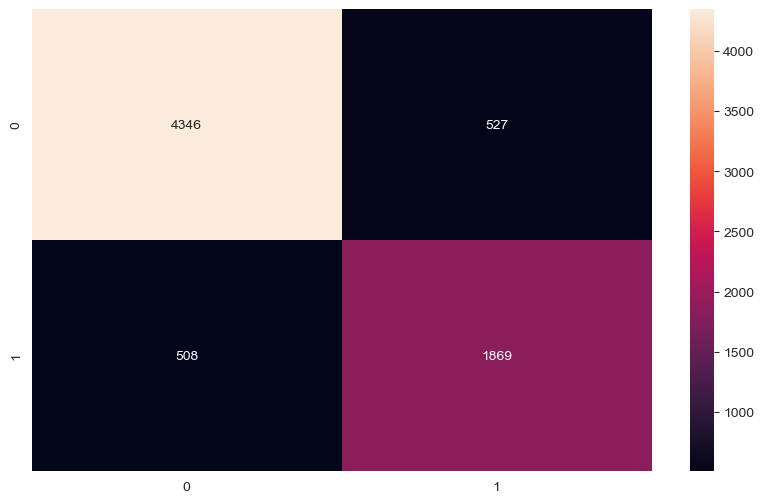

In [280]:
results = {}
for model_name, model in models.items():
    print(f"training {model_name}....")
    #training the model
    model.fit(X_train_scaled, y_train)
    
    # predicting model
    y_pred = model.predict(X_test_scaled)
    
    #evaluating the model
    accuracy = accuracy_score(y_test,y_pred)
    report = classification_report(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': matrix
    }
    print(f"{model_name} Classification Report")
    print(report)
    sns.heatmap(matrix, annot=True, fmt="g")
    plt.show()

### The Random forest remains the best model, but we have to fine tune and compare it with the rest

In [281]:
# Calculate all metrics for each model
def evaluate_model(name, y_true, y_pred, y_prob):
    """Print evaluation metrics for one model."""
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
    print(classification_report(y_true, y_pred,
                                 target_names=['No Default', 'Default']))
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_prob)
    }

results = []
results.append(evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob))
results.append(evaluate_model('Decision Tree',       y_test, dt_pred, dt_prob))
results.append(evaluate_model('Random Forest',       y_test, rf_pred, rf_prob))


  Logistic Regression
  Accuracy:  0.7964
  Precision: 0.7297
  Recall:    0.6020
  F1 Score:  0.6598
  ROC-AUC:   0.8612
              precision    recall  f1-score   support

  No Default       0.82      0.89      0.85      4873
     Default       0.73      0.60      0.66      2377

    accuracy                           0.80      7250
   macro avg       0.78      0.75      0.76      7250
weighted avg       0.79      0.80      0.79      7250


  Decision Tree
  Accuracy:  0.8321
  Precision: 0.7634
  Recall:    0.7072
  F1 Score:  0.7342
  ROC-AUC:   0.8818
              precision    recall  f1-score   support

  No Default       0.86      0.89      0.88      4873
     Default       0.76      0.71      0.73      2377

    accuracy                           0.83      7250
   macro avg       0.81      0.80      0.81      7250
weighted avg       0.83      0.83      0.83      7250


  Random Forest
  Accuracy:  0.8590
  Precision: 0.8501
  Recall:    0.6920
  F1 Score:  0.7630
  ROC-AUC

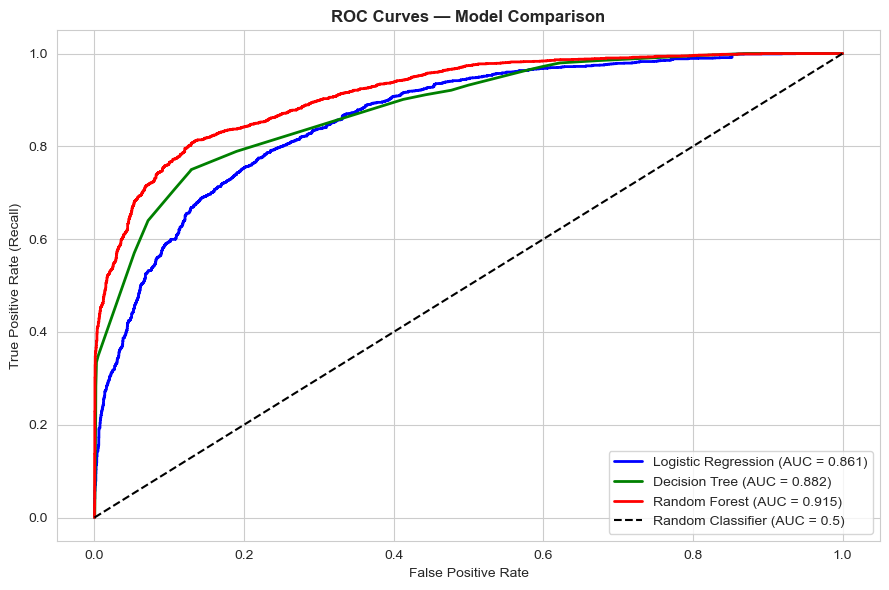

In [282]:
# ROC Curves — visual comparison of all models
plt.figure(figsize=(9, 6))

for name, probs, color in [('Logistic Regression', lr_prob, 'blue'),
                             ('Decision Tree',       dt_prob, 'green'),
                             ('Random Forest',       rf_prob, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc:.3f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Model Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [283]:
# Summary comparison table
results_df = pd.DataFrame(results).set_index('Model').round(4)
print("=== Model Comparison Summary ===")
print(results_df.to_string())
print()
print("Best model per metric:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    print(f"  {metric:<12}: {results_df[metric].idxmax()} ({results_df[metric].max():.4f})")

=== Model Comparison Summary ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.7964     0.7297  0.6020  0.6598   0.8612
Decision Tree          0.8321     0.7634  0.7072  0.7342   0.8818
Random Forest          0.8590     0.8501  0.6920  0.7630   0.9145

Best model per metric:
  Accuracy    : Random Forest (0.8590)
  Precision   : Random Forest (0.8501)
  Recall      : Decision Tree (0.7072)
  F1          : Random Forest (0.7630)
  ROC-AUC     : Random Forest (0.9145)


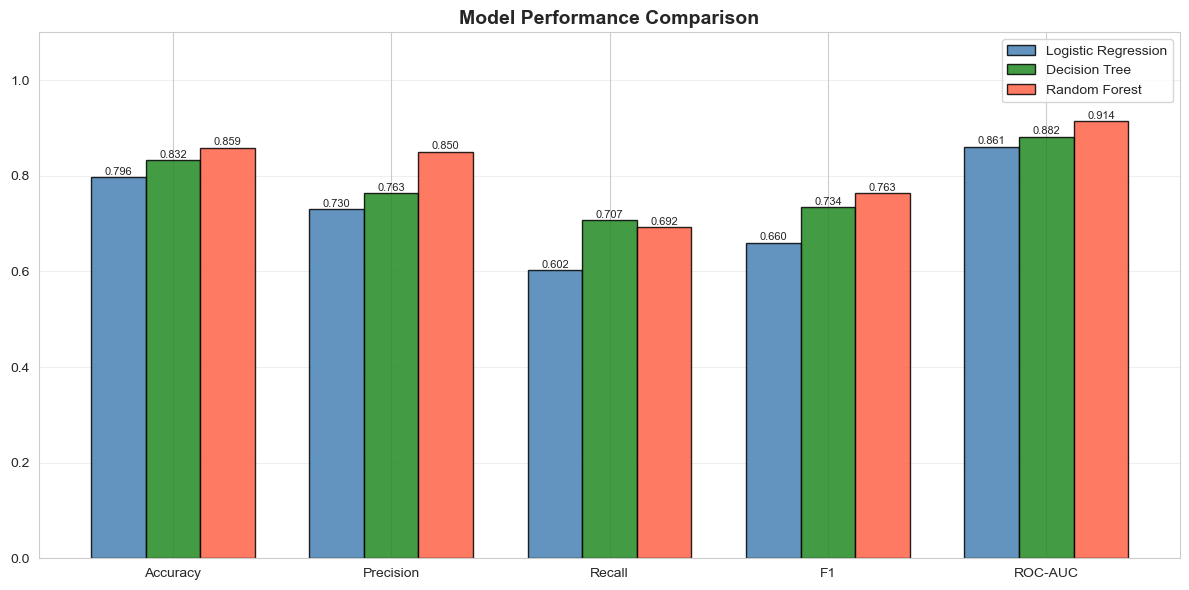

In [284]:
# Metrics bar chart — visual model comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

for i, (model_name, color) in enumerate(zip(results_df.index,
                                             ['steelblue', 'forestgreen', 'tomato'])):
    vals = results_df.loc[model_name, metrics].values
    bars = ax.bar(x + i*width, vals, width, label=model_name,
                  color=color, alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### *Hyperparameter tuning

In [285]:
from sklearn.model_selection import GridSearchCV

In [286]:
RandomForestClassifier(random_state=42,class_weight="balanced")

RandomForestClassifier(class_weight='balanced', random_state=42)

In [287]:
from sklearn.model_selection import GridSearchCV

In [288]:
parameter_grid = {
    "n_estimators": [50,100, 200],
    "max_depth": [None,10,20,30],
    "min_samples_split": [2, 5 ,10],
    "min_samples_leaf": [1, 2,4]}

In [289]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42,class_weight="balanced"),
                           param_grid = parameter_grid,
                           scoring = "f1",
                           cv=5,
                           n_jobs=-1)

In [290]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [291]:
print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [292]:
best_rf = grid_search.best_estimator_

In [293]:
y_pred_best_rf = best_rf.predict(X_test_scaled)

In [294]:
print("fine tuned Random forest classifier")
report= classification_report(y_test, y_pred_best_rf)
print(report)

fine tuned Random forest classifier
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      4873
           1       0.83      0.82      0.83      2377

    accuracy                           0.89      7250
   macro avg       0.87      0.87      0.87      7250
weighted avg       0.89      0.89      0.89      7250



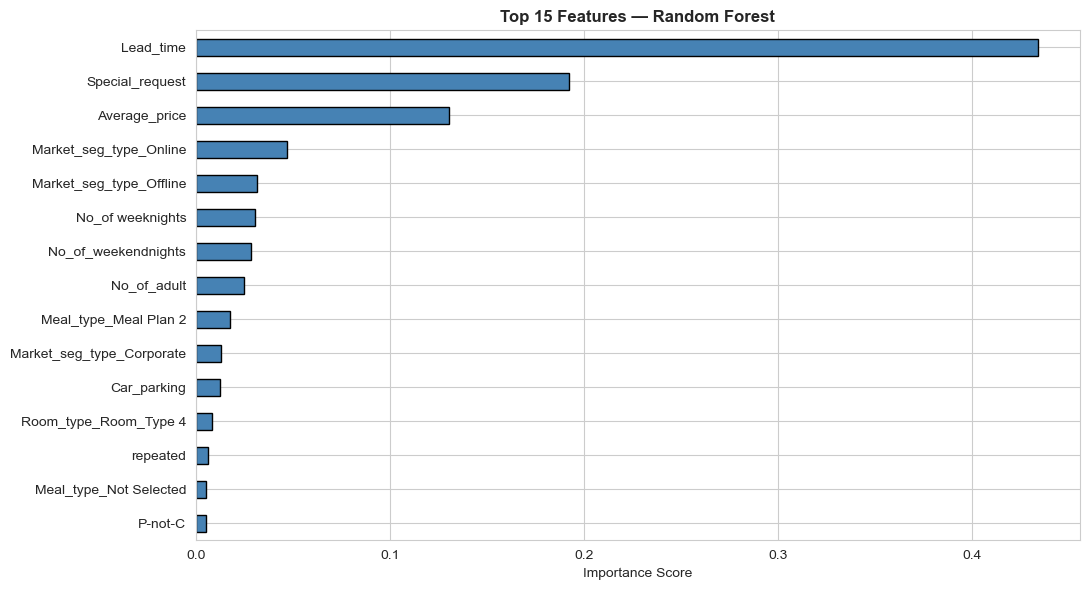

In [295]:
# Feature Importance from Random Forest
# Shows which features contributed most to predictions
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(11, 6))
feature_importance.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Top 15 Features — Random Forest', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
##  Conclusion

### Cappy Project Concluded
An end-to-end ML pipeline: data loading → EDA → cleaning → preprocessing → training → evaluation.




In [297]:
# Final summary
print("=" * 55)
print("  FINAL RESULTS")
print("=" * 55)
print(results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].to_string())
print()
print(f"Best F1:      {results_df['F1'].idxmax()}")
print(f"Best ROC-AUC: {results_df['ROC-AUC'].idxmax()}")
print()
print("Pipeline complete!")
print()
print("fine tuned Random forest classifier")
report= classification_report(y_test, y_pred_best_rf)
print(report)

  FINAL RESULTS
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.7964     0.7297  0.6020  0.6598   0.8612
Decision Tree          0.8321     0.7634  0.7072  0.7342   0.8818
Random Forest          0.8590     0.8501  0.6920  0.7630   0.9145

Best F1:      Random Forest
Best ROC-AUC: Random Forest

Pipeline complete!

fine tuned Random forest classifier
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      4873
           1       0.83      0.82      0.83      2377

    accuracy                           0.89      7250
   macro avg       0.87      0.87      0.87      7250
weighted avg       0.89      0.89      0.89      7250

